---
title: "Intensity gallery — plotting every λ(t) kernel"
---

# Intensity gallery

This notebook plots every intensity kernel in the `methane_pod.intensity` module. Each one is an `equinox.Module` that takes a time array `t` [days] and returns an intensity `λ(t)` [events day⁻¹]. Physical motivation, parameter meanings, and suggested priors live in the module docstrings; here we focus on the shapes of the curves themselves so the gallery reads like a catalog.

The kernels are arranged by the dominant temporal scale they encode, from **sub-daily** (diurnal, shift, PRV recharge, batch venting) through **daily-to-synoptic** (operational schedules, barometric pumping) to **annual** (seasonal, wetland thaw, landfill, feedlot).

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from methane_pod import intensity

# short window — emphasises diurnal / sub-daily structure
t_short = jnp.linspace(0, 5, 2001)
# long window — emphasises seasonal structure
t_long = jnp.linspace(0, 730, 8001)

## 1. Baseline: the homogeneous Poisson process

A flat λ(t) = λ₀. The simplest model, corresponding to a chronically leaking, passive facility (abandoned wells, legacy pipes). The absence of temporal structure is its defining feature.

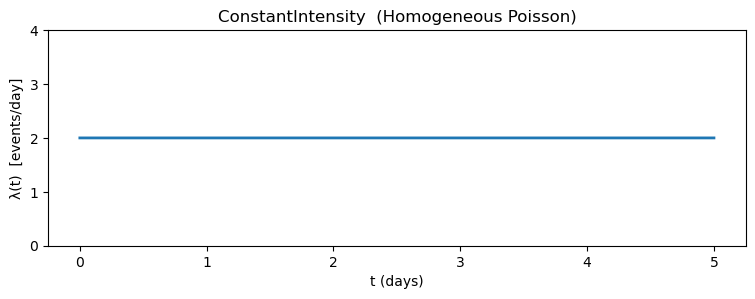

In [2]:
model = intensity.ConstantIntensity(lambda_0=2.0)
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t_short, model(t_short), lw=2)
ax.set_ylim(0, 4)
ax.set_xlabel("t (days)")
ax.set_ylabel("λ(t)  [events/day]")
ax.set_title("ConstantIntensity  (Homogeneous Poisson)")
plt.show()

## 2. Diurnal and seasonal sinusoids

Sub-daily thermal cycling on storage tanks (diurnal), annual temperature cycles on biogenic sources (seasonal). The peak phase matters a great deal for satellite sampling because polar-orbiting platforms cross every point on the Earth at a fixed local time.

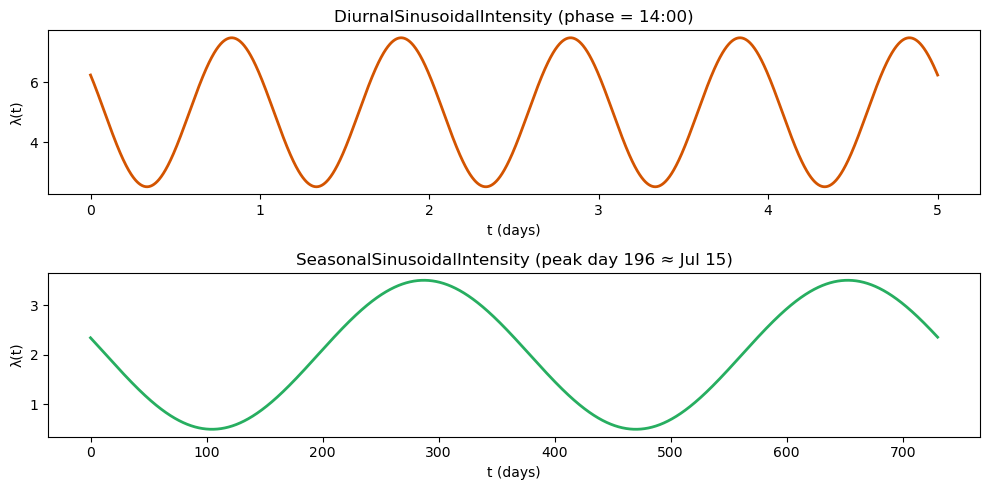

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)

diurnal = intensity.DiurnalSinusoidalIntensity(lambda_0=5.0, amplitude=2.5)
axes[0].plot(t_short, diurnal(t_short), color="#d35400", lw=2)
axes[0].set_title("DiurnalSinusoidalIntensity (phase = 14:00)")
axes[0].set_xlabel("t (days)"); axes[0].set_ylabel("λ(t)")

seasonal = intensity.SeasonalSinusoidalIntensity(lambda_0=2.0, amplitude=1.5)
axes[1].plot(t_long, seasonal(t_long), color="#27ae60", lw=2)
axes[1].set_title("SeasonalSinusoidalIntensity (peak day 196 ≈ Jul 15)")
axes[1].set_xlabel("t (days)"); axes[1].set_ylabel("λ(t)")

fig.tight_layout(); plt.show()

## 3. Multi-scale compounds

Landfills, feedlots, and many biogenic sources exhibit *both* sub-daily and annual modulation. The additive compound (`DiurnalSeasonalIntensity`) layers the two; the multiplicative one (`SeasonallyModulatedDiurnalIntensity`) encodes the physically cleaner fact that diurnal amplitude itself grows in summer and shrinks in winter.

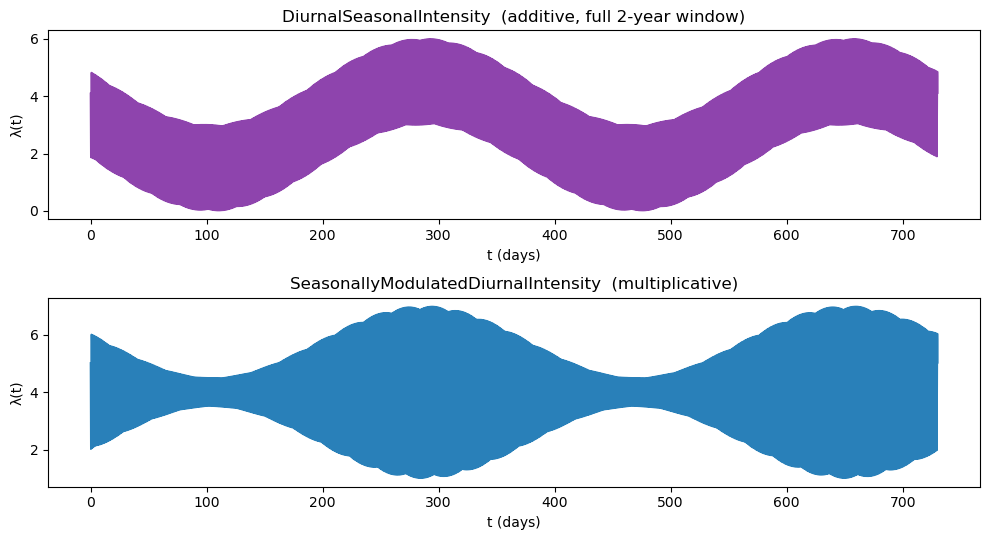

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=False)

add_compound = intensity.DiurnalSeasonalIntensity(
    lambda_0=3.0, amp_diurnal=1.5, amp_seasonal=1.5
)
axes[0].plot(t_long, add_compound(t_long), color="#8e44ad", lw=1.2)
axes[0].set_title("DiurnalSeasonalIntensity  (additive, full 2-year window)")
axes[0].set_xlabel("t (days)"); axes[0].set_ylabel("λ(t)")

mul_compound = intensity.SeasonallyModulatedDiurnalIntensity(
    lambda_0=4.0, amp_summer=3.0, amp_winter=0.5
)
axes[1].plot(t_long, mul_compound(t_long), color="#2980b9", lw=1.2)
axes[1].set_title("SeasonallyModulatedDiurnalIntensity  (multiplicative)")
axes[1].set_xlabel("t (days)"); axes[1].set_ylabel("λ(t)")

fig.tight_layout(); plt.show()

## 4. Operational & hazard models

Two qualitatively different kernels: the **operational schedule** (sigmoid on/off duty cycle, captures crew-shift step functions differentiably enough for NUTS) and the **Weibull renewal hazard** (increasing failure rate since the last event — think of a pressure-relief valve that must recharge between vents). The Weibull one is evaluated on *elapsed-since-last* time, not calendar time.

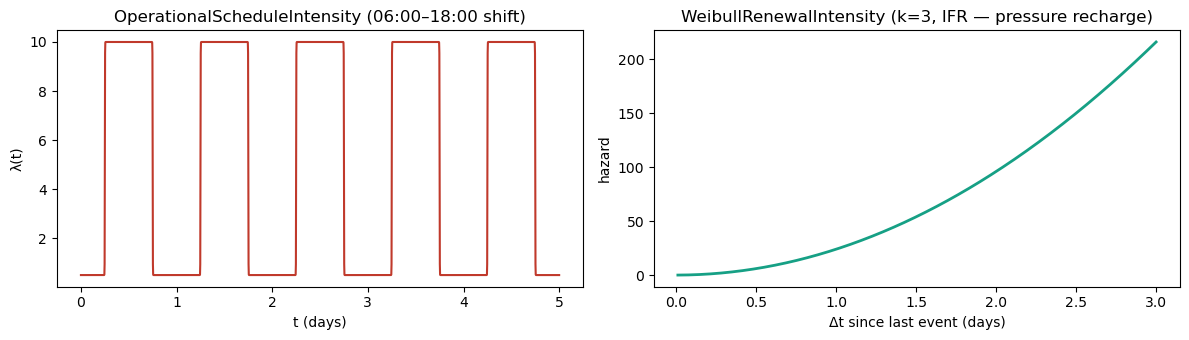

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

op = intensity.OperationalScheduleIntensity(
    lambda_active=10.0, lambda_idle=0.5, start_hour=6.0, end_hour=18.0
)
axes[0].plot(t_short, op(t_short), color="#c0392b", lw=1.5)
axes[0].set_title("OperationalScheduleIntensity (06:00–18:00 shift)")
axes[0].set_xlabel("t (days)"); axes[0].set_ylabel("λ(t)")

weibull = intensity.WeibullRenewalIntensity(scale=0.5, shape=3.0)
dt_grid = jnp.linspace(0.01, 3.0, 400)
axes[1].plot(dt_grid, weibull(dt_grid), color="#16a085", lw=2)
axes[1].set_title("WeibullRenewalIntensity (k=3, IFR — pressure recharge)")
axes[1].set_xlabel("Δt since last event (days)"); axes[1].set_ylabel("hazard")

fig.tight_layout(); plt.show()

## 5. Periodic batch venting (impulse train)

Glycol dehydrators, liquid unloading, longwall shearer cycles — a narrow Gaussian pulse on a low background, repeated with period $P$. The pulse width is parameterised as a fraction of the period to keep the shape scale-invariant.

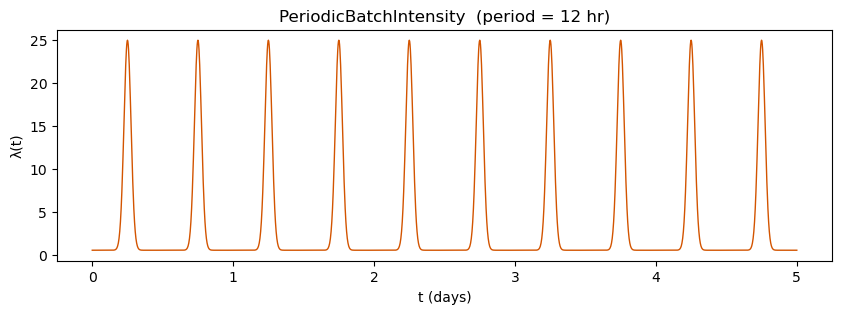

In [6]:
batch = intensity.PeriodicBatchIntensity(
    lambda_background=0.5, lambda_peak=25.0,
    period_days=0.5, duty_fraction=0.05,
)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_short, batch(t_short), color="#d35400", lw=1.0)
ax.set_xlabel("t (days)"); ax.set_ylabel("λ(t)")
ax.set_title("PeriodicBatchIntensity  (period = 12 hr)")
plt.show()

## 6. Multi-scale domain-specific kernels

Four kernels that combine 2-3 time scales with a physically meaningful parameterisation. These are the models you'd use in an actual inventory study where you know the source type.

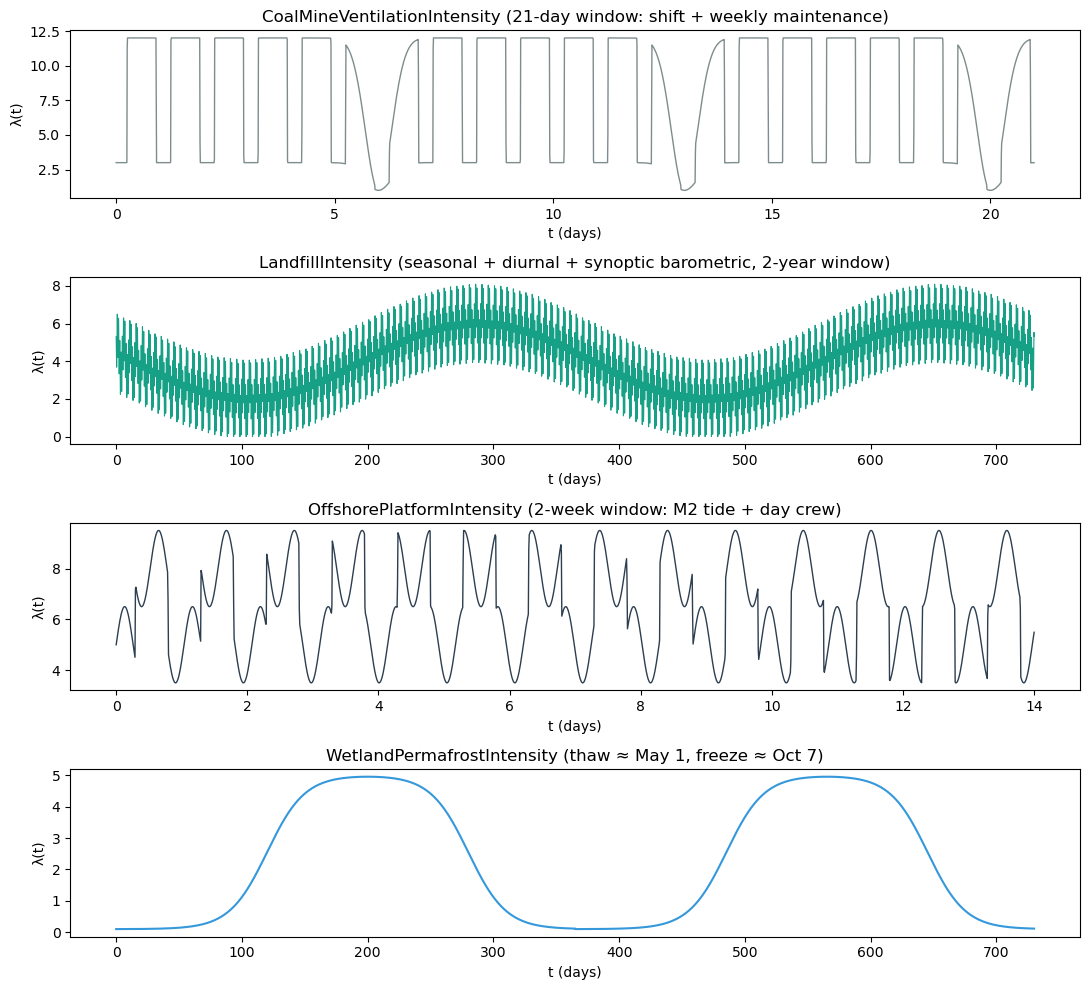

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=False)

# Coal mine: shift + weekly maintenance (21 days so you see 3 weeks)
t_3week = jnp.linspace(0, 21, 3001)
coal = intensity.CoalMineVentilationIntensity(
    lambda_extraction=12.0, lambda_maintenance=1.0, lambda_idle=3.0
)
axes[0].plot(t_3week, coal(t_3week), color="#7f8c8d", lw=1.0)
axes[0].set_title("CoalMineVentilationIntensity (21-day window: shift + weekly maintenance)")
axes[0].set_xlabel("t (days)"); axes[0].set_ylabel("λ(t)")

# Landfill: seasonal + diurnal + barometric
landfill = intensity.LandfillIntensity(
    lambda_0=4.0, amp_seasonal=2.0, amp_diurnal=1.2, amp_barometric=1.0
)
axes[1].plot(t_long, landfill(t_long), color="#16a085", lw=0.8)
axes[1].set_title("LandfillIntensity (seasonal + diurnal + synoptic barometric, 2-year window)")
axes[1].set_xlabel("t (days)"); axes[1].set_ylabel("λ(t)")

# Offshore: semidiurnal tide + operational
t_2week = jnp.linspace(0, 14, 2001)
offshore = intensity.OffshorePlatformIntensity(
    lambda_0=5.0, amp_tidal=1.5, amp_operational=3.0
)
axes[2].plot(t_2week, offshore(t_2week), color="#2c3e50", lw=1.0)
axes[2].set_title("OffshorePlatformIntensity (2-week window: M2 tide + day crew)")
axes[2].set_xlabel("t (days)"); axes[2].set_ylabel("λ(t)")

# Wetland / permafrost: sigmoid-gated seasonal
wetland = intensity.WetlandPermafrostIntensity(
    lambda_peak=5.0, lambda_frozen=0.1
)
axes[3].plot(t_long, wetland(t_long), color="#3498db", lw=1.5)
axes[3].set_title("WetlandPermafrostIntensity (thaw ≈ May 1, freeze ≈ Oct 7)")
axes[3].set_xlabel("t (days)"); axes[3].set_ylabel("λ(t)")

fig.tight_layout(); plt.show()

## 7. Livestock feedlot — bimodal diurnal + seasonal

Cattle are fed twice a day; rumen microbial activity peaks 1–3 hours after each feeding. The resulting intensity is bimodal within each day. Seasonal modulation on top comes from temperature-sensitive manure-lagoon emissions.

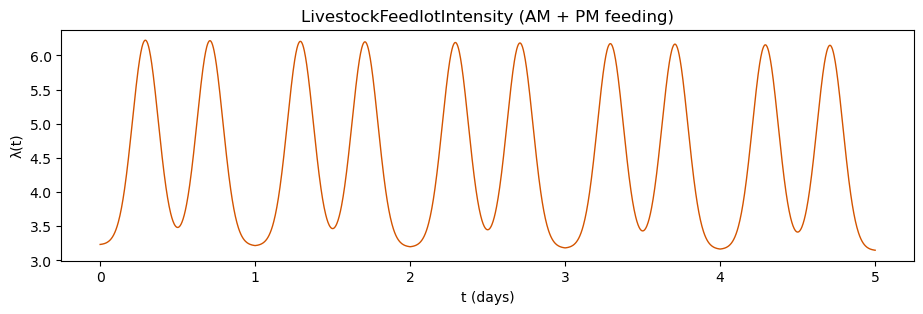

In [8]:
feedlot = intensity.LivestockFeedlotIntensity(
    lambda_0=3.0, amp_feeding=3.0, amp_seasonal=1.0
)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_short, feedlot(t_short), color="#d35400", lw=1.0)
ax.set_xlabel("t (days)"); ax.set_ylabel("λ(t)")
ax.set_title("LivestockFeedlotIntensity (AM + PM feeding)")
plt.show()

## Registry roll-call

Every class in the catalog is also available via the `INTENSITY_REGISTRY` dict keyed by a short string — handy for config-driven workflows.

In [9]:
print(f"Registered intensity modules: {len(intensity.INTENSITY_REGISTRY)}")
for key, cls in intensity.INTENSITY_REGISTRY.items():
    print(f"  {key:<22s} -> {cls.__name__}")

Registered intensity modules: 13
  constant               -> ConstantIntensity
  diurnal                -> DiurnalSinusoidalIntensity
  seasonal               -> SeasonalSinusoidalIntensity
  diurnal_seasonal       -> DiurnalSeasonalIntensity
  modulated_diurnal      -> SeasonallyModulatedDiurnalIntensity
  operational            -> OperationalScheduleIntensity
  weibull_renewal        -> WeibullRenewalIntensity
  periodic_batch         -> PeriodicBatchIntensity
  coal_mine              -> CoalMineVentilationIntensity
  landfill               -> LandfillIntensity
  offshore               -> OffshorePlatformIntensity
  wetland_permafrost     -> WetlandPermafrostIntensity
  livestock_feedlot      -> LivestockFeedlotIntensity
